In [54]:
import pandas as pd

# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/CienciaDeDatos/dataset_movilidad_limpio.csv')

# Convertimos fecha_hora a tipo datetime real
df['fecha'] = pd.to_datetime(df['fecha_hora'])

# Extraemos features útiles de la fecha
df['hora'] = df['fecha'].dt.hour
df['dia_semana'] = df['fecha'].dt.dayofweek
df['mes'] = df['fecha'].dt.month

display(df.head())

,fecha_hora,demanda_viajes,hora,dia_semana,dia_semana_num,mes,es_fin_de_semana,hora_sin,hora_cos,es_festivo,tipo_zona,fecha
0,2014-04-01 00:00:00,5,0,1,1,4,0,0.000000,1.000000,0,"Universidad (zona de práctica, NYC)",2014-04-01 00:00:00
1,2014-04-01 01:00:00,6,1,1,1,4,0,0.258819,0.965926,0,"Universidad (zona de práctica, NYC)",2014-04-01 01:00:00
2,2014-04-01 02:00:00,1,2,1,1,4,0,0.500000,0.866025,0,"Universidad (zona de práctica, NYC)",2014-04-01 02:00:00
3,2014-04-01 03:00:00,4,3,1,1,4,0,0.707107,0.707107,0,"Universidad (zona de práctica, NYC)",2014-04-01 03:00:00
4,2014-04-01 04:00:00,6,4,1,1,4,0,0.866025,0.500000,0,"Universidad (zona de práctica, NYC)",2014-04-01 04:00:00


In [55]:
from sklearn.preprocessing import LabelEncoder
from joblib import dump

labelencoders = {}

# Codificamos SOLO columnas de texto que sean categorías reales
# (ejemplo: tipo_zona = "centro"/"norte"/"sur")
string_columns = df.select_dtypes(include='object').columns.tolist()

# Excluimos columnas que no queremos tocar:
# - fecha_hora: ya la convertimos a datetime, no la necesitamos como texto
# - demanda_viajes: es NUMÉRICA (nuestro target), no se codifica
exclude_cols = ['fecha_hora', 'demanda_viajes']
string_columns = [col for col in string_columns if col not in exclude_cols]

for columna in string_columns:
    le = LabelEncoder()
    df[f'{columna}_encoded'] = le.fit_transform(df[columna])
    labelencoders[columna] = le

dump(labelencoders, '/content/drive/MyDrive/CienciaDeDatos/Viajes_lter.joblib')

print("Columnas codificadas:", string_columns)
display(df.head())

Columnas codificadas: ['tipo_zona']


,fecha_hora,demanda_viajes,hora,dia_semana,dia_semana_num,mes,es_fin_de_semana,hora_sin,hora_cos,es_festivo,tipo_zona,fecha,tipo_zona_encoded
0,2014-04-01 00:00:00,5,0,1,1,4,0,0.000000,1.000000,0,"Universidad (zona de práctica, NYC)",2014-04-01 00:00:00,0
1,2014-04-01 01:00:00,6,1,1,1,4,0,0.258819,0.965926,0,"Universidad (zona de práctica, NYC)",2014-04-01 01:00:00,0
2,2014-04-01 02:00:00,1,2,1,1,4,0,0.500000,0.866025,0,"Universidad (zona de práctica, NYC)",2014-04-01 02:00:00,0
3,2014-04-01 03:00:00,4,3,1,1,4,0,0.707107,0.707107,0,"Universidad (zona de práctica, NYC)",2014-04-01 03:00:00,0
4,2014-04-01 04:00:00,6,4,1,1,4,0,0.866025,0.500000,0,"Universidad (zona de práctica, NYC)",2014-04-01 04:00:00,0


In [56]:
festture = ['hora', 'dia_semana', 'mes', 'es_fin_de_semana',
            'hora_sin', 'hora_cos', 'es_festivo', 'tipo_zona_encoded']

label = 'demanda_viajes'  # el número real, SIN encoding

# Verificamos que todas las columnas existan (por si acaso)
X_cols = [col for col in festture if col in df.columns]
if len(X_cols) != len(festture):
    print(f"Faltan columnas: {list(set(festture) - set(df.columns))}")

X = df[X_cols]
y = df[label]

print(f"Features usadas: {X_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features usadas: ['hora', 'dia_semana', 'mes', 'es_fin_de_semana', 'hora_sin', 'hora_cos', 'es_festivo', 'tipo_zona_encoded']
X shape: (4391, 8), y shape: (4391,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train length: {len(y_train)}")
print(f"y_test length: {len(y_test)}")

# Guardamos train y test con la columna target incluida
X_train_with_label = X_train.copy()
X_train_with_label['label'] = y_train

X_test_with_label = X_test.copy()
X_test_with_label['label'] = y_test

X_train_with_label.to_csv('/content/drive/MyDrive/CienciaDeDatos/Viajes_train.csv', index=False)
X_test_with_label.to_csv('/content/drive/MyDrive/CienciaDeDatos/Viajes_test.csv', index=False)

print("Train y test guardados correctamente.")

X_train shape: (3512, 8)
X_test shape: (879, 8)
y_train length: 3512
y_test length: 879
Train y test guardados correctamente.


## Analisis y Estudio de los de datos

In [58]:
df_train = df.copy()

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
%matplotlib inline

In [60]:
df_train['demanda_viajes'].describe()

,demanda_viajes
count,4391.000000
mean,44.295377
std,35.981386
min,0.000000
25%,17.000000
50%,37.000000
75%,61.000000
max,251.000000


/tmp/ipykernel_64607/3555391014.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['demanda_viajes']);


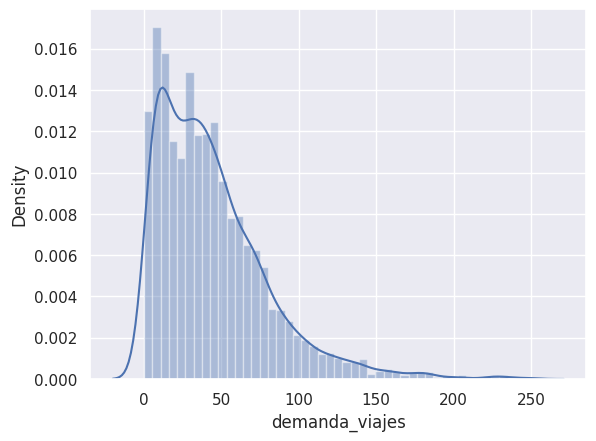

In [61]:
sns.distplot(df_train['demanda_viajes']);

In [62]:
df_train['demanda_viajes'].skew()

np.float64(1.5627182074167092)

In [63]:
df_train['demanda_viajes'].kurt()

np.float64(3.6536276570513557)

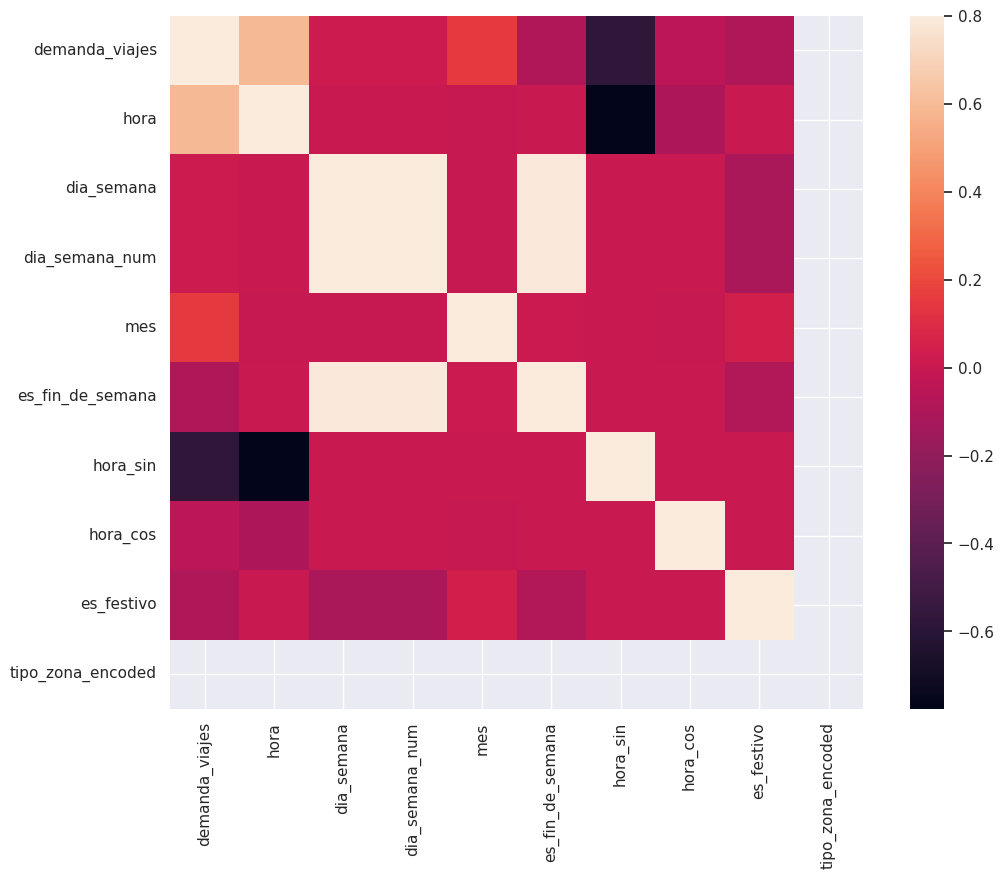

In [64]:
cormat = df_train.select_dtypes(include=np.number).corr()
f,ax = plt.subplots(figsize=(12,9))
sns.heatmap(cormat,vmax=.8,square=True);

In [65]:
k = 10
cols = cormat.nlargest(k,'demanda_viajes')['demanda_viajes'].index
cols

Index(['demanda_viajes', 'hora', 'mes', 'dia_semana', 'dia_semana_num',
       'hora_cos', 'es_fin_de_semana', 'es_festivo', 'hora_sin',
       'tipo_zona_encoded'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


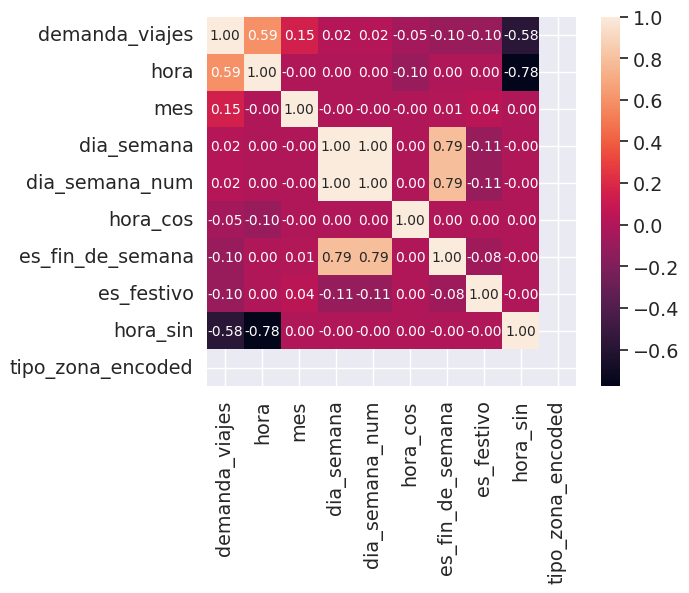

In [66]:
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm,cbar=True,annot=True,square=True,fmt='.2f',annot_kws={'size':10},yticklabels=cols.values,xticklabels=cols.values)
plt.show()

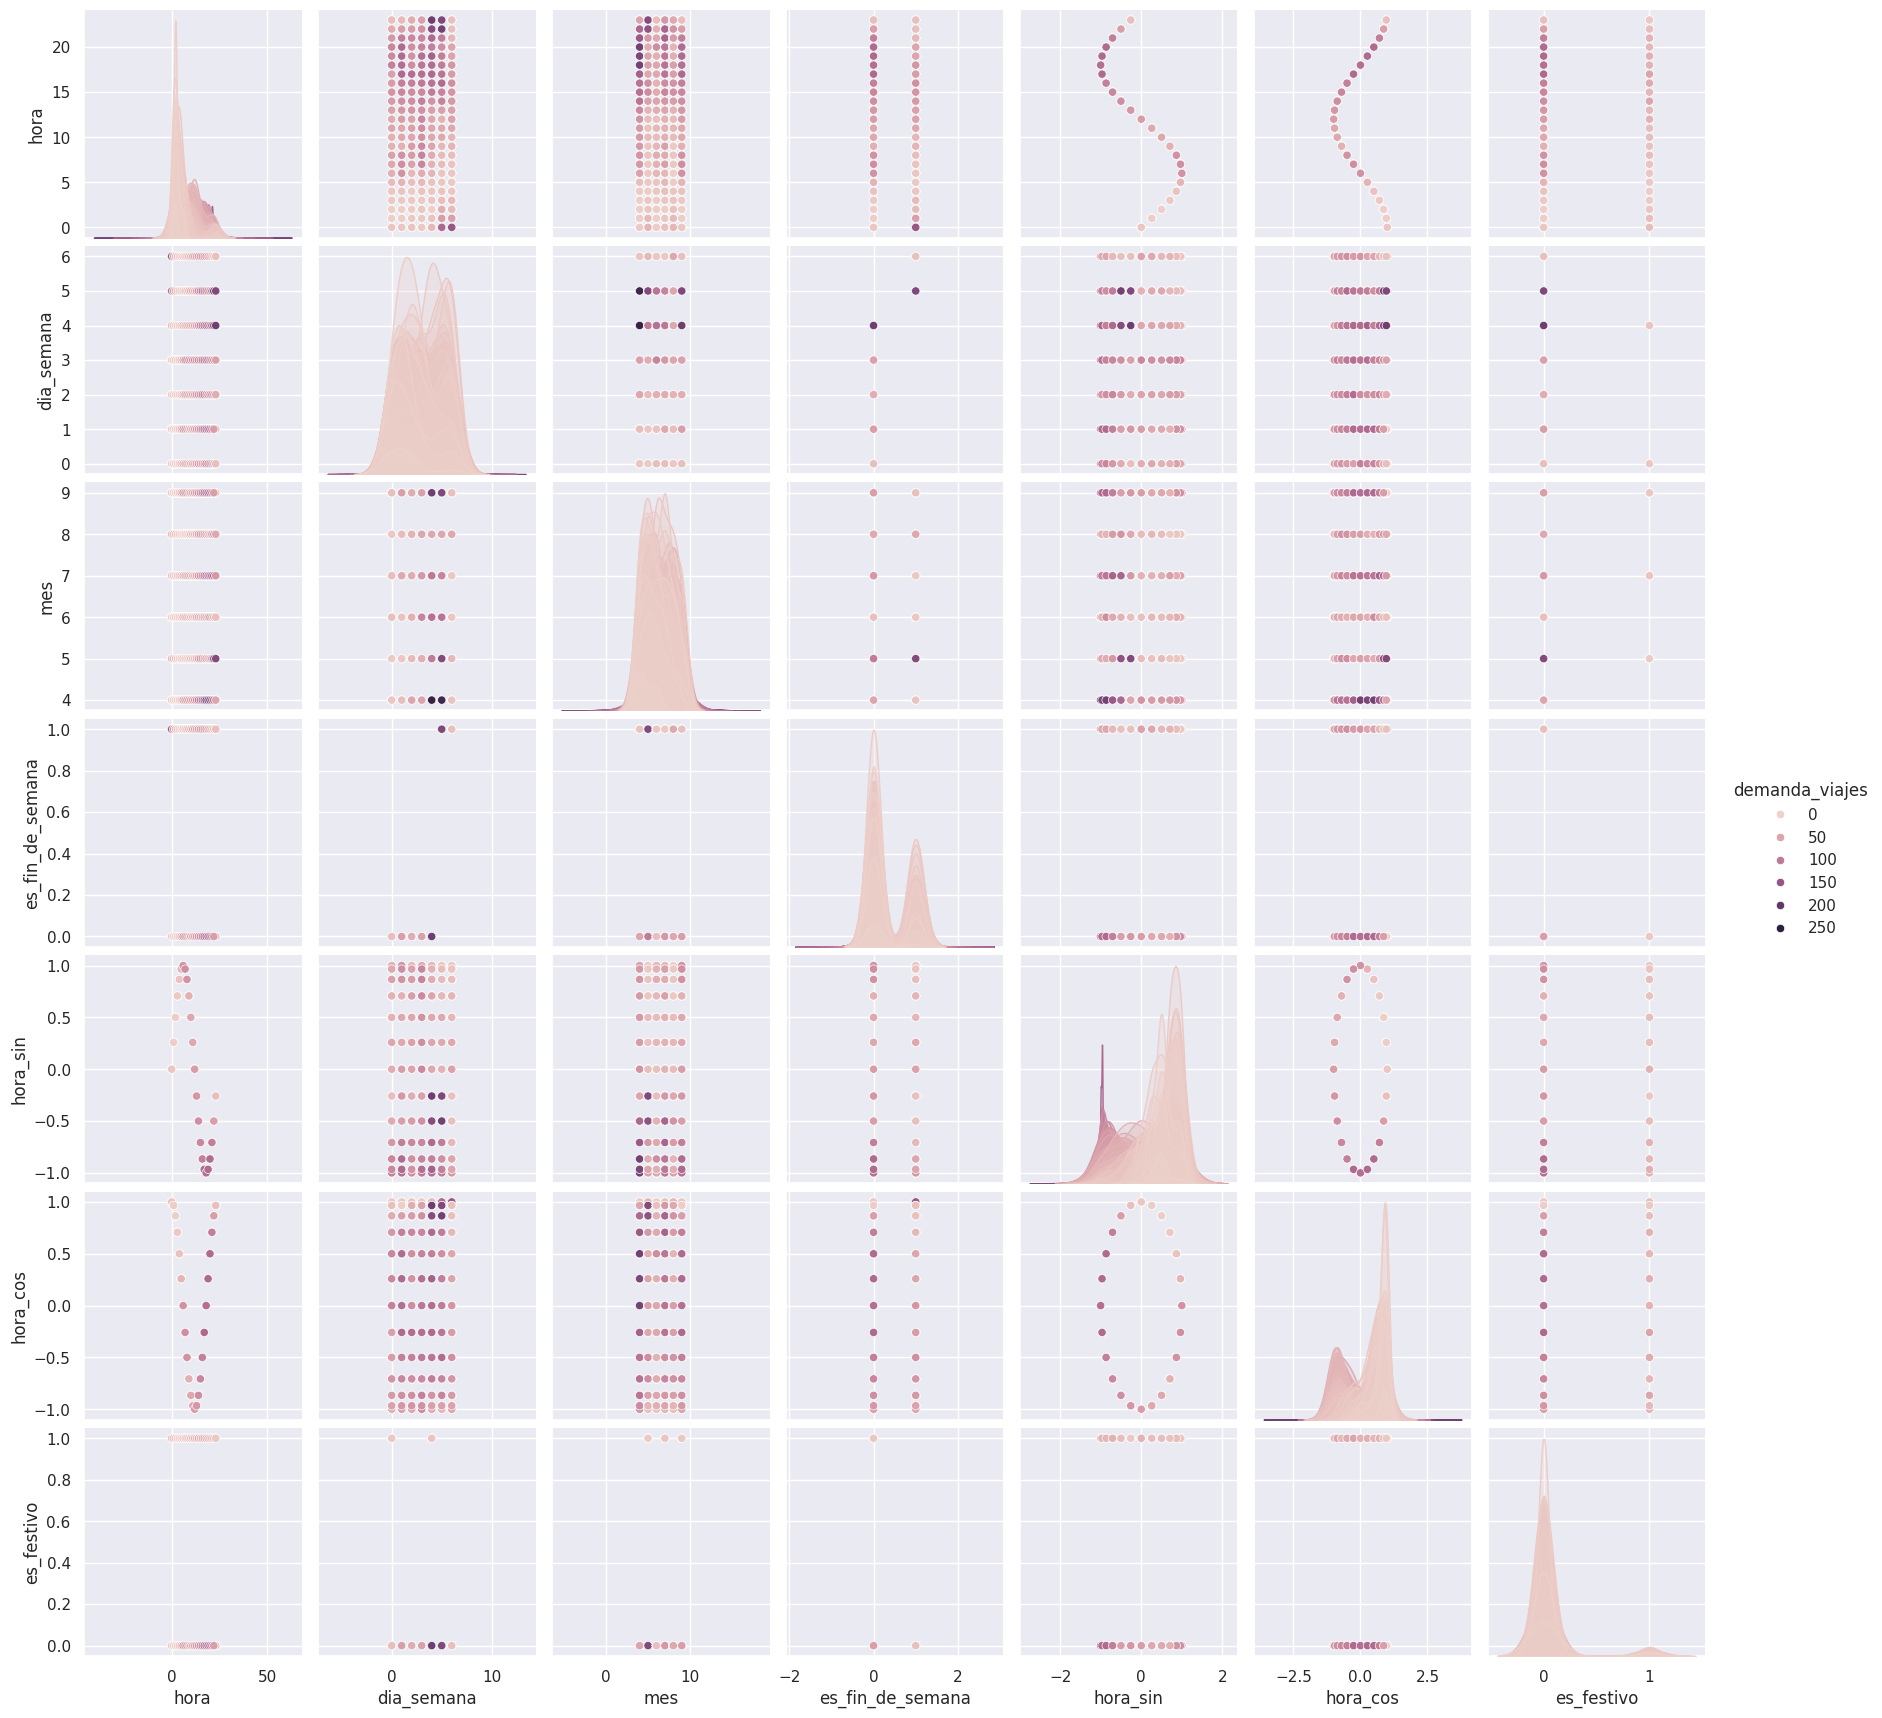

In [67]:
sns.set()

cols_numericas = ['hora', 'dia_semana', 'mes', 'es_fin_de_semana',
                   'hora_sin', 'hora_cos', 'es_festivo']

sns.pairplot(df_train, vars=cols_numericas, hue='demanda_viajes', height=2.5)
plt.show()

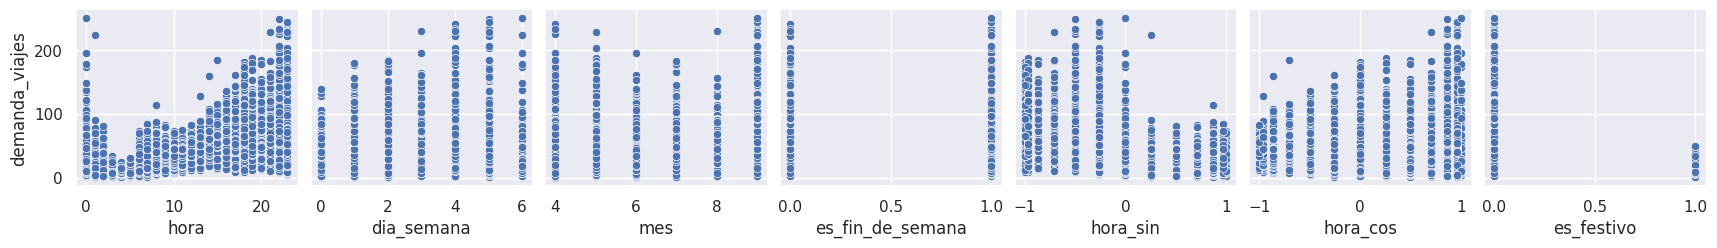

In [68]:
cols_numericas = ['hora', 'dia_semana', 'mes', 'es_fin_de_semana',
                   'hora_sin', 'hora_cos', 'es_festivo', 'demanda_viajes']

sns.pairplot(df_train, x_vars=cols_numericas[:-1], y_vars=['demanda_viajes'], height=2.5)
plt.show()